Given the root of a binary tree, return true if it is a valid binary search tree, otherwise return false.

A valid binary search tree satisfies the following constraints:

The left subtree of every node contains only nodes with keys less than the node's key.

The right subtree of every node contains only nodes with keys greater than the node's key.

Both the left and right subtrees are also binary search trees.

Example 1:

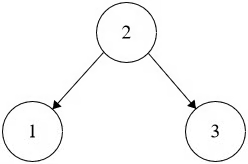

Input: root = [2,1,3]

Output: true

Example 2:

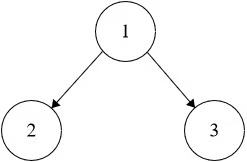

Input: root = [1,2,3]

Output: false

Explanation: The root node's value is 1 but its left child's value is 2 which is greater than 1.

In [ ]:
from typing import Optional, List
from collections import deque

In [ ]:
# Definition for a binary tree node.
class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right

class Solution:
    def isValidBST(self, root: Optional[TreeNode]) -> bool:
        def helper(node, lower=float('-inf'), upper=float('inf')):
            if not node:
                return True
            val = node.val
            if val <= lower or val >= upper:
                return False
            if not helper(node.right, val, upper):
                return False
            if not helper(node.left, lower, val):
                return False
            return True
        return helper(root)

# Brute Force

Intuition

To check if a tree is a valid Binary Search Tree (BST), every node must satisfy:

All values in its left subtree are strictly less than the node’s value.

All values in its right subtree are strictly greater than the node’s value.

In this brute force idea, for each node we:

Check all nodes in its left subtree to confirm they are < node.val.

Check all nodes in its right subtree to confirm they are > node.val.

Then recursively repeat the same process for each child as a new root.

This re-checks many nodes multiple times, so it’s correct but not efficient.

Algorithm

If the tree is empty → return true.

For the current node:

Run a helper on its left subtree to ensure every value < current value.

Run a helper on its right subtree to ensure every value > current value.

If either check fails → return false.

Recursively:

Check that the left child's subtree is a valid BST.

Check that the right child's subtree is a valid BST.

If all checks pass for every node → return true.

In [ ]:
# Time Complexity: O(n^2)
# Space Complexity: O(n)
class Solution:
    left_check = staticmethod(lambda val, limit: val < limit)
    right_check = staticmethod(lambda val, limit: val > limit)

    def isValidBST(self, root: Optional[TreeNode]) -> bool:
        if not root:
            return True

        if (not self.isValid(root.left, root.val, self.left_check) or
            not self.isValid(root.right, root.val, self.right_check)):
            return False

        return self.isValidBST(root.left) and self.isValidBST(root.right)

    def isValid(self, root: Optional[TreeNode], limit: int, check) -> bool:
        if not root:
            return True
        if not check(root.val, limit):
            return False
        return (self.isValid(root.left, limit, check) and
                self.isValid(root.right, limit, check))

# DFS

Intuition

A Binary Search Tree isn’t just about each node being smaller or larger than its parent — every node must fit within a valid value range decided by all its ancestors.

For the root, the allowed range is (-∞, +∞).

When you go left, the node’s value must be less than the parent, so the upper bound becomes smaller.

When you go right, the node’s value must be greater than the parent, so the lower bound becomes larger.

As we move down the tree, we keep tightening these bounds.

If any node violates its allowed range → the tree is not a BST.

This checks all BST rules efficiently in one DFS pass.

Algorithm

Start DFS from the root with the initial valid range (-∞, +∞).

For each node:

If node.val is not strictly between (left, right) → return false.

Recursively:

Validate the left subtree with updated range (left, node.val).

Validate the right subtree with updated range (node.val, right).

If all nodes satisfy their ranges → it is a valid BST.

In [ ]:
# Time Complexity: O(n)
# Space Complexity: O(n)
class Solution:
    def isValidBST(self, root: Optional[TreeNode]) -> bool:
        def valid(node, left, right):
            if not node:
                return True
            if not (left < node.val < right):
                return False

            return valid(node.left, left, node.val) and valid(
                node.right, node.val, right
            )

        return valid(root, float("-inf"), float("inf"))

# BFS

Intuition

A tree is a valid BST only if every node lies within a valid range defined by its ancestors.

Instead of using recursion, we can use a queue (BFS) to check this level by level.

Start with the root, whose valid range is (-∞, +∞).

When moving to the left child, its maximum allowed value becomes the current node’s value.

When moving to the right child, its minimum allowed value becomes the current node’s value.

If any node violates its allowed range, the tree is not a BST.

This way, we verify every node exactly once using BFS.

Algorithm

If the tree is empty → return true.

Push (root, -∞, +∞) into a queue.

While the queue is not empty:

Pop (node, leftBound, rightBound).

If node.val is not between (leftBound, rightBound), return false.

Push the left child with range (leftBound, node.val).

Push the right child with range (node.val, rightBound).

If all nodes satisfy their ranges → return true.

In [ ]:
# Time Complexity: O(n)
# Space Complexity: O(n)
class Solution:
    def isValidBST(self, root: Optional[TreeNode]) -> bool:
        if not root:
            return True

        q = deque([(root, float("-inf"), float("inf"))])

        while q:
            node, left, right = q.popleft()
            if not (left < node.val < right):
                return False
            if node.left:
                q.append((node.left, left, node.val))
            if node.right:
                q.append((node.right, node.val, right))

        return True